Лабораторна робота 2. Озимок, 4-9

---



# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import io
import requests

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
tables = pd.read_html(io.StringIO(response.text))

df = tables[2]

df.head()

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


2.	Визначити розмір датасета.

In [ ]:
print(f"Розмір датасета (рядки, стовпці): {df.shape}")

Розмір датасета (рядки, стовпці): (222, 4)


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [ ]:
if isinstance(df.columns, pd.MultiIndex):
    df.columns = ['_'.join(str(c) for c in col).strip() for col in df.columns]

selected_columns = [df.columns[0], df.columns[1], df.columns[2], df.columns[3]]
df = df[selected_columns].copy()

df.columns = ['Country', 'IMF_2026', 'WorldBank_2025', 'UN_2024']
df.head()

,Country,IMF_2026,WorldBank_2025,UN_2024
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [ ]:
numeric_cols = ['IMF_2026', 'WorldBank_2025', 'UN_2024']

for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace('—', '', regex=False)
    df[col] = df[col].str.replace('–', '', regex=False)
    df[col] = df[col].str.replace('-', '', regex=False)
    df[col] = df[col].str.replace(',', '', regex=False)
    df[col] = df[col].str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
print("Кількість пропусків до заповнення:")
print(df.isna().sum())

Кількість пропусків до заповнення:
Country            0
IMF_2026          31
WorldBank_2025    35
UN_2024            9
dtype: int64


In [ ]:
for col in numeric_cols:
    mean_val = df[col].mean()
    df[col] = df[col].fillna(mean_val)


In [ ]:
print("\nКількість пропусків після заповнення:")
print(df.isna().sum())


Кількість пропусків після заповнення:
Country           0
IMF_2026          0
WorldBank_2025    0
UN_2024           0
dtype: int64


5. Ще раз вивести датасет

In [ ]:
df.head(10)

,Country,IMF_2026,WorldBank_2025,UN_2024
0,World,126295331.0,118350166.0,111565144.0
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
6,India,4153191.0,3956067.0,3952244.0
7,France,3596094.0,3366316.0,3160443.0
8,Italy,2738164.0,2551557.0,2380825.0
9,Russia,2656452.0,2561310.0,2173386.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [ ]:
print(f"Кількість повних дублікатів: {df.duplicated().sum()}")
print(f"Кількість дублікатів за назвою країни: {df.duplicated(subset=['Country']).sum()}")

Кількість повних дублікатів: 0
Кількість дублікатів за назвою країни: 0


In [ ]:
df = df.drop_duplicates(subset=['Country']).reset_index(drop=True)

In [ ]:
print(f"Новий розмір датасета: {df.shape}")

Новий розмір датасета: (222, 4)


7.	Вивести описову статистику датасету describe()

In [ ]:
df.describe()

,IMF_2026,WorldBank_2025,UN_2024
count,2.220000e+02,2.220000e+02,2.220000e+02
mean,1.319229e+06,1.255590e+06,1.043818e+06
std,8.838876e+06,8.288461e+06,7.830341e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,1.932375e+04,2.003400e+04,9.170750e+03
50%,1.039745e+05,9.986350e+04,4.322450e+04
75%,7.726678e+05,1.041520e+06,3.048545e+05
max,1.262953e+08,1.183502e+08,1.115651e+08


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [ ]:
df['Diff_IMF_WB'] = (df['IMF_2026'] - df['WorldBank_2025']).abs()

top_diff = df.sort_values(by='Diff_IMF_WB', ascending=False)[['Country', 'IMF_2026', 'WorldBank_2025', 'Diff_IMF_WB']].head(5)
print(top_diff)

                   Country      IMF_2026  WorldBank_2025   Diff_IMF_WB
0                    World  1.262953e+08     118350166.0  7.945165e+06
1            United States  3.238392e+07      30769700.0  1.614220e+06
2               China[n 1]  2.085159e+07      19498039.0  1.353554e+06
197           Sint Maarten  1.319229e+06          1888.0  1.317341e+06
146  Palestine[n 11][n 12]  1.319229e+06         17167.0  1.302062e+06


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [ ]:
corr_matrix = df[['IMF_2026', 'WorldBank_2025', 'UN_2024']].corr()

In [ ]:
print("Матриця кореляції:")
print(corr_matrix)

Матриця кореляції:
                IMF_2026  WorldBank_2025   UN_2024
IMF_2026        1.000000        0.999497  0.998998
WorldBank_2025  0.999497        1.000000  0.998864
UN_2024         0.998998        0.998864  1.000000


Обчислити середнє значення за стовпцями

In [ ]:
print("Середні значення за стовпцями:")
print(df[['IMF_2026', 'WorldBank_2025', 'UN_2024']].mean())

Середні значення за стовпцями:
IMF_2026          1.319229e+06
WorldBank_2025    1.255590e+06
UN_2024           1.043818e+06
dtype: float64


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [ ]:
df['Std_Dev'] = df[['IMF_2026', 'WorldBank_2025', 'UN_2024']].std(axis=1)

top_std = df.sort_values(by='Std_Dev', ascending=False)[['Country', 'Std_Dev']].head(5)
print(top_std)

                   Country       Std_Dev
0                    World  7.372704e+06
1            United States  1.543508e+06
2               China[n 1]  1.068002e+06
197           Sint Maarten  7.606303e+05
146  Palestine[n 11][n 12]  7.520782e+05


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [ ]:
records = []
for col in ['IMF_2026', 'WorldBank_2025', 'UN_2024']:
    max_row = df.loc[df[col].idxmax()]
    min_row = df.loc[df[col].idxmin()]
    records.append({
        'Source/Year': col,
        'Max Country': max_row['Country'],
        'Max Value': max_row[col],
        'Min Country': min_row['Country'],
        'Min Value': min_row[col]
    })

pd.DataFrame(records)

,Source/Year,Max Country,Max Value,Min Country,Min Value
0,IMF_2026,World,126295331.0,Tuvalu,65.0
1,WorldBank_2025,World,118350166.0,Tuvalu,57.0
2,UN_2024,World,111565144.0,Tuvalu,56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

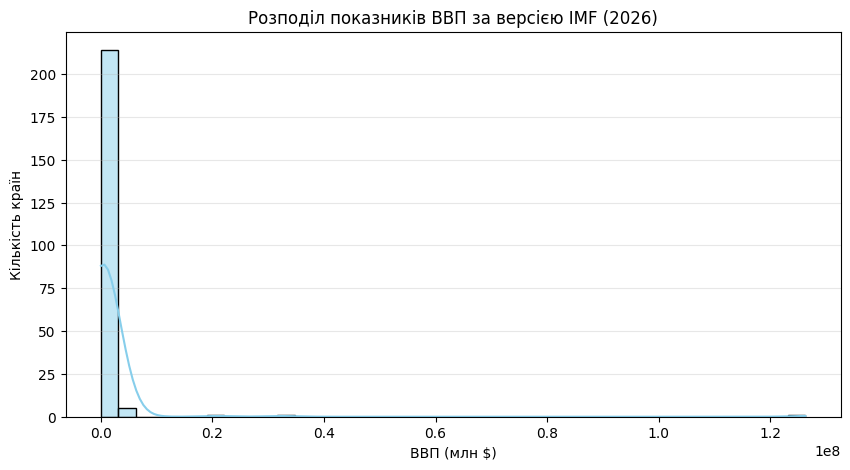

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['IMF_2026'], bins=40, kde=True, color='skyblue')
plt.title('Розподіл показників ВВП за версією IMF (2026)')
plt.xlabel('ВВП (млн $)')
plt.ylabel('Кількість країн')
plt.grid(axis='y', alpha=0.3)
plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [ ]:
for col in ['IMF_2026', 'WorldBank_2025', 'UN_2024']:
    df[f'Share_{col}'] = (df[col] / df[col].sum()) * 100

print(df[['Country', 'Share_IMF_2026', 'Share_WorldBank_2025', 'Share_UN_2024']].head(10))

          Country  Share_IMF_2026  Share_WorldBank_2025  Share_UN_2024
0           World       43.123505             42.458818      48.144944
1   United States       11.057480             11.038811      12.643291
2      China[n 1]        7.119770              6.995036       8.088721
3         Germany        1.861877              1.812048       2.010951
4           Japan        1.495295              1.591141       1.737475
5  United Kingdom        1.456213              1.435952       1.590609
6           India        1.418106              1.419262       1.705556
7          France        1.227885              1.207686       1.363861
8           Italy        0.934945              0.915386       1.027424
9          Russia        0.907045              0.918885       0.937905


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

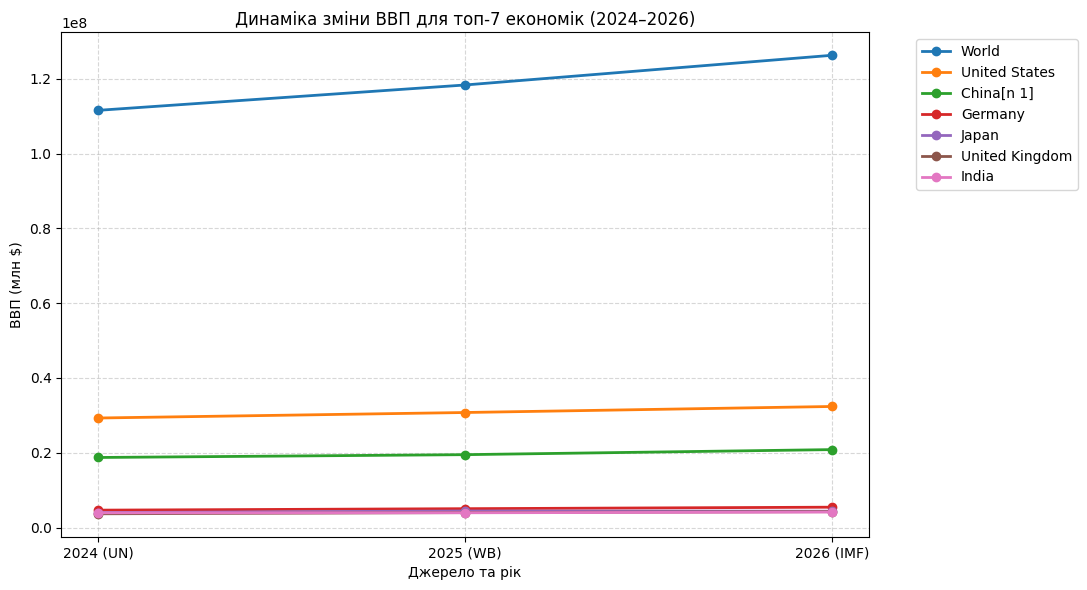

In [ ]:
top_countries = df.sort_values(by='IMF_2026', ascending=False).head(7)

years = ['2024 (UN)', '2025 (WB)', '2026 (IMF)']

plt.figure(figsize=(11, 6))
for _, row in top_countries.iterrows():
    values = [row['UN_2024'], row['WorldBank_2025'], row['IMF_2026']]
    plt.plot(years, values, marker='o', label=row['Country'], linewidth=2)

plt.title('Динаміка зміни ВВП для топ-7 економік (2024–2026)')
plt.xlabel('Джерело та рік')
plt.ylabel('ВВП (млн $)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()